In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import json
import os
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from misophonia_dataset.interface import get_data_dir

In [3]:
def bootstrap_category_performance(
    json_path: Path | str,
    n_boot: int,
    metric_name: str = "si_snr_improvement",
    seed: int = 0,
    n_workers: int | None = None,
) -> dict[str, pd.DataFrame]:
    aliases = {
        "chewing_gum": "chewing",
        "plastic_crumpling": "plastic_crumbling",
    }

    with Path(json_path).open("r") as f:
        data: list[dict[str, Any]] = json.load(f)

    rows: list[dict[str, Any]] = []

    for item in data:
        meta = item["sample_metadata"]
        metrics = item["metrics"]

        if metric_name not in metrics:
            continue

        fg_ids = meta.get("fg_freesound_ids", [])
        if len(fg_ids) != 1:
            raise ValueError(f"Expected exactly one foreground source ID, got {fg_ids}")

        fg_categories = meta.get("fg_categories", [])
        if len(fg_categories) == 0:
            continue

        category = aliases.get(str(fg_categories[0]), str(fg_categories[0]))

        rows.append(
            {
                "eval_idx": item.get("idx"),
                "fg_source_id": int(fg_ids[0]),
                "category": category,
                "category_pretty": category.replace("_", " ").title(),
                "metric": float(metrics[metric_name]),
            }
        )

    mixture_rows = pd.DataFrame(rows)

    source_rows = (
        mixture_rows
        .groupby(["category", "category_pretty", "fg_source_id"], as_index=False)
        .agg(
            source_mean=("metric", "mean"),
            source_std=("metric", "std"),
            n_mixtures=("metric", "size"),
        )
    )

    category_summary = (
        source_rows
        .groupby(["category", "category_pretty"], as_index=False)
        .agg(
            n_sources=("fg_source_id", "nunique"),
            n_mixtures=("n_mixtures", "sum"),
            observed_mean=("source_mean", "mean"),
            observed_source_sd=("source_mean", "std"),
            observed_median_source_mean=("source_mean", "median"),
            median_mixtures_per_source=("n_mixtures", "median"),
        )
    )

    categories = category_summary["category"].tolist()
    pretty_names = dict(zip(category_summary["category"], category_summary["category_pretty"]))

    category_groups = [
        (category, mixture_rows.loc[mixture_rows["category"] == category])
        for category in categories
    ]

    child_seeds = np.random.SeedSequence(seed).spawn(len(category_groups))

    def bootstrap_one_category(
        category: str,
        category_df: pd.DataFrame,
        child_seed: np.random.SeedSequence,
    ) -> tuple[str, np.ndarray]:
        rng = np.random.default_rng(child_seed)

        source_values = [
            g["metric"].to_numpy(dtype=np.float64)
            for _, g in category_df.groupby("fg_source_id", sort=False)
        ]

        n_sources = len(source_values)
        source_boot_means = np.empty((n_sources, n_boot), dtype=np.float64)

        for i, values in enumerate(source_values):
            idx = rng.integers(0, len(values), size=(n_boot, len(values)), dtype=np.int32)
            source_boot_means[i] = values[idx].mean(axis=1)

        sampled_source_idx = rng.integers(
            0,
            n_sources,
            size=(n_boot, n_sources),
            dtype=np.int32,
        )

        boot_values = source_boot_means[
            sampled_source_idx,
            np.arange(n_boot)[:, None],
        ].mean(axis=1)

        return category, boot_values

    max_workers = n_workers or min(len(category_groups), os.cpu_count() or 1)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        boot_results = list(
            executor.map(
                lambda args: bootstrap_one_category(*args),
                [
                    (category, category_df, child_seed)
                    for (category, category_df), child_seed in zip(category_groups, child_seeds)
                ],
            )
        )

    boot_means = pd.DataFrame({category: values for category, values in boot_results})
    boot_means = boot_means[categories]
    boot_means = boot_means.rename(columns=pretty_names)

    category_summary["boot_mean"] = [
        boot_means[pretty_names[c]].mean() for c in category_summary["category"]
    ]
    category_summary["ci_low"] = [
        boot_means[pretty_names[c]].quantile(0.025) for c in category_summary["category"]
    ]
    category_summary["ci_high"] = [
        boot_means[pretty_names[c]].quantile(0.975) for c in category_summary["category"]
    ]
    category_summary["observed_rank"] = category_summary["observed_mean"].rank(
        ascending=False,
        method="min",
    )

    category_summary = (
        category_summary
        .sort_values("observed_mean", ascending=False)
        .reset_index(drop=True)
    )

    ranks = boot_means.rank(axis=1, ascending=False, method="min")
    n_categories = len(boot_means.columns)

    rank_rows: list[dict[str, Any]] = []

    for category in category_summary["category"]:
        category_pretty = pretty_names[category]
        category_ranks = ranks[category_pretty].to_numpy()

        row: dict[str, Any] = {
            "category": category,
            "category_pretty": category_pretty,
            "mean_rank": category_ranks.mean(),
            "median_rank": np.median(category_ranks),
            "p_rank_1": np.mean(category_ranks == 1),
            "p_top_2": np.mean(category_ranks <= 2),
            "p_top_3": np.mean(category_ranks <= 3),
            "p_bottom_1": np.mean(category_ranks == n_categories),
            "p_bottom_2": np.mean(category_ranks >= n_categories - 1),
        }

        for rank in range(1, n_categories + 1):
            row[f"p_rank_{rank}"] = np.mean(category_ranks == rank)

        rank_rows.append(row)

    rank_probabilities = (
        pd.DataFrame(rank_rows)
        .sort_values("mean_rank")
        .reset_index(drop=True)
    )

    pairwise_win_probabilities = pd.DataFrame(
        index=boot_means.columns,
        columns=boot_means.columns,
        dtype=float,
    )

    for a in boot_means.columns:
        for b in boot_means.columns:
            pairwise_win_probabilities.loc[a, b] = (
                0.5 if a == b else (boot_means[a].to_numpy() > boot_means[b].to_numpy()).mean()
            )

    return {
        "mixture_rows": mixture_rows,
        "source_rows": source_rows,
        "category_summary": category_summary,
        "rank_probabilities": rank_probabilities,
        "pairwise_win_probabilities": pairwise_win_probabilities,
        "boot_means": boot_means,
    }

In [6]:
json_path = get_data_dir() / "model-aux-ft-all-gt-clean-mix" / "eval_results/" / "ema_best_by_ema_test_results.json"
assert json_path.exists(), f"Expected results json at {json_path}"

results = bootstrap_category_performance(
    json_path=json_path,
    n_boot=100_000,
    metric_name="si_snr_improvement",
    seed=0,
    n_workers=8,
)

category_summary = results["category_summary"]
rank_probabilities = results["rank_probabilities"]
pairwise_win_probabilities = results["pairwise_win_probabilities"]
boot_means = results["boot_means"]

category_summary

,category,category_pretty,n_sources,n_mixtures,observed_mean,observed_source_sd,observed_median_source_mean,median_mixtures_per_source,boot_mean,ci_low,ci_high,observed_rank
0,knife_cutting,Knife Cutting,45,859,11.768703,5.770235,13.190643,19.0,11.772798,9.935874,13.529145,1.0
1,swallowing,Swallowing,15,335,10.168485,5.367271,11.433128,19.0,10.169976,7.250890,12.822476,2.0
2,clearing_throat,Clearing Throat,73,1540,10.062482,3.058837,10.677602,19.0,10.063636,9.253483,10.858942,3.0
3,plastic_crumbling,Plastic Crumbling,111,2102,10.049461,3.384814,10.321314,19.0,10.051307,9.285291,10.801091,4.0
4,typing,Typing,118,2278,9.569433,3.136564,9.663750,19.0,9.569584,8.888247,10.239036,5.0
5,water_drops,Water Drops,60,1175,8.709613,6.153910,8.914614,19.0,8.704451,7.090622,10.305351,6.0
6,chewing,Chewing,38,709,7.946516,4.076682,9.045532,19.0,7.947152,6.463524,9.387686,7.0
7,human_breathing,Human Breathing,45,1002,7.857608,3.400988,8.519722,19.0,7.859924,6.743476,8.957278,8.0


In [15]:
# The means if you simple take the raw data and per calculate the mean per category, with no consideration of sources or bootstrapping
category_means = (
    results["mixture_rows"]
    .groupby("category", as_index=False)
    .agg(mean_metric=("metric", "mean"))
    .sort_values("mean_metric", ascending=False)
    .reset_index(drop=True)
)
category_means["category_pretty"] = category_means["category"].apply(lambda c: c.replace("_", " ").title())
category_means

,category,mean_metric,category_pretty
0,knife_cutting,11.707033,Knife Cutting
1,swallowing,11.004210,Swallowing
2,clearing_throat,10.310662,Clearing Throat
3,plastic_crumbling,10.073395,Plastic Crumbling
4,typing,9.643509,Typing
5,water_drops,8.855987,Water Drops
6,human_breathing,8.090323,Human Breathing
7,chewing,7.977417,Chewing


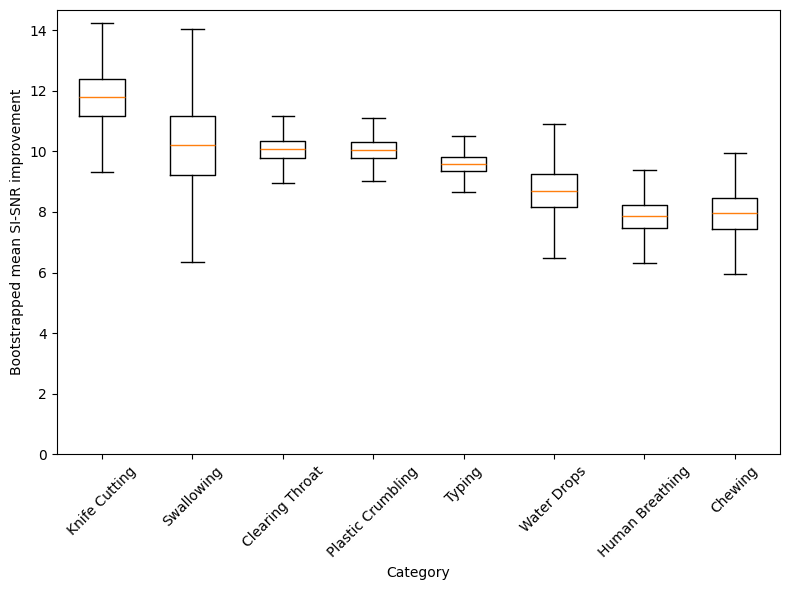

In [16]:
# order by non-bootstrapped observed mean
ordered_categories = category_means["category_pretty"].tolist()


plot_df = boot_means[ordered_categories]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [plot_df[col].to_numpy() for col in plot_df.columns],
    tick_labels=plot_df.columns,
    showfliers=False,
)

ax.set_ylim(0, None)

ax.set_ylabel("Bootstrapped mean SI-SNR improvement")
ax.set_xlabel("Category")
ax.tick_params(axis="x", rotation=45)


fig.tight_layout()

fig.savefig(get_data_dir() / "report_figs" / "category_performance_bootstrap.pdf", dpi=300)
plt.show()